In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime
from geopy.distance import geodesic
from sklearn.cluster import KMeans

In [2]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [7]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km

In [9]:
def categorize_location(city_pop):
    if city_pop > 50000:
        return 1
    elif city_pop > 10000:
        return 2
    else:
        return 3

In [10]:
# Function to compute distance between merchant and transaction locations
def calculate_distance_between_locations(lat1, long1, lat2, long2):
    return geodesic((lat1, long1), (lat2, long2)).kilometers


In [11]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
#     df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    # Apply the function to create a new feature
    df['distance_to_merchant'] = df.apply(
        lambda row: calculate_distance_between_locations(row['lat'], row['long'], row['merch_lat'], row['merch_long']),
        axis=1
    )
    
    df['location_type'] = df['city_pop'].apply(categorize_location)
    
    # Apply K-Means clustering
    coords = df[['lat', 'long']]
    kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
    df['location_cluster'] = kmeans.labels_
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
#     te = TargetEncoder()
#     le_job = le.fit_transform(df['job'])
#     df['le_job'] = le_job
#     le_street = le.fit_transform(df['street'])
#     df['le_street'] = le_street
#     le_merchant = le.fit_transform(df['merchant'])
#     df['le_merchant'] = le_merchant
#     le_city = le.fit_transform(df['city'])
#     df['le_city'] = le_city
#     le_state = le.fit_transform(df['state'])
#     le_category = le.fit_transform(df['category'])
#     df['le_category'] = le_category
    
    return df

In [12]:
df = data_processing('../fraudTrain.csv')

In [17]:
df.dtypes

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
year                              int32
month                             int32
day                               int32


In [18]:
category_counts = df.select_dtypes(include='object').nunique()

In [19]:
category_counts

merchant         693
category          14
first            352
last             481
gender             2
street           983
city             894
state             51
job              494
trans_num    1296675
dtype: int64

In [ ]:
 #approach1

In [27]:
df['city'].value_counts().head(20)

city
Birmingham      5617
San Antonio     5130
Utica           5105
Phoenix         5075
Meridian        5060
Thomas          4634
Conway          4613
Cleveland       4604
Warren          4599
Houston         4168
Burbank         4159
Naples          4155
Arcadia         4096
Indianapolis    4073
Brandon         4044
Fulton          3977
Lahoma          3646
Allentown       3639
Lakeland        3635
Dallas          3629
Name: count, dtype: int64

In [33]:
# df['merchant'].value_counts()[df['city'].value_counts() < 1000].count()



In [3]:
# df = pd.read_csv('../fraudTrain.csv')

In [15]:
from category_encoders.cat_boost import CatBoostEncoder

In [30]:
cbe_encoder = CatBoostEncoder()

In [31]:
categorical_col = ['merchant', 'category', 'street', 'city', 'state', 'job']
train_cbe = cbe_encoder.fit_transform(df[categorical_col], df['is_fraud'])

In [32]:
train_cbe

,merchant,category,street,city,state,job
0,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
1,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
2,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
3,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
4,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
...,...,...,...,...,...,...
1296670,0.002625,0.002478,0.005952,0.005952,0.005702,0.005339
1296671,0.002288,0.001651,0.015077,0.015077,0.005994,0.015077
1296672,0.001082,0.001651,0.005317,0.005317,0.004998,0.006104
1296673,0.002097,0.001651,0.003955,0.003955,0.006005,0.003955


In [34]:
train_cbe.columns = ['cbe_' + col for col in categorical_col]


In [36]:
train_cbe.sample()

,cbe_merchant,cbe_category,cbe_street,cbe_city,cbe_state,cbe_job
1042679,0.003448,0.002339,0.000007,0.000007,0.003591,0.004123


In [37]:
df_cbe = pd.concat([df, train_cbe], axis=1)


In [38]:
df_cbe.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,cbe_merchant,cbe_category,cbe_street,cbe_city,cbe_state,cbe_job
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,1900-01-01 00:00:18,36,78.773821,3,1,0,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,1900-01-01 00:00:44,46,30.216618,3,0,0,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,1900-01-01 00:00:51,62,108.102912,3,0,1,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,1900-01-01 00:01:16,57,95.685115,3,0,1,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019,1,1,1900-01-01 00:03:06,38,77.702395,3,4,1,0.005789,0.005789,0.005789,0.005789,0.005789,0.005789


In [41]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'cbe_street', 'job', 'first', 'last', 'time', 'cc_num', 'trans_date_trans_time', 'trans_num','dob','distance_to_merchant'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df_cbe.drop(columns=columns_to_drop)



In [42]:
df_1.sample()

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,year,month,day,age,location_type,location_cluster,le_gender,cbe_merchant,cbe_category,cbe_city,cbe_state,cbe_job
197291,3.44,81005,38.2352,-104.66,151815,1334188285,38.087175,-105.584901,0,2019,4,11,36,1,3,1,0.002841,0.001972,0.000037,0.005322,0.000009


In [43]:
df_test = data_processing('../fraudTest.csv')

In [44]:
cbe_encoder = CatBoostEncoder()
test_cbe = cbe_encoder.fit_transform(df_test[categorical_col], df_test['is_fraud'])
test_cbe.columns = ['cbe_' + col for col in categorical_col]
df_cbe_test = pd.concat([df_test, test_cbe], axis=1)

In [45]:
df_cbe_test.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,cbe_merchant,cbe_category,cbe_street,cbe_city,cbe_state,cbe_job
497369,2020-12-19 09:57:24,4979422371139333,"fraud_Kutch, Hermiston and Farrell",gas_transport,75.3,Kelly,Zimmerman,F,1893 Katie Tunnel,Westerville,NE,68881,41.4193,-99.3844,73,Product designer,1935-02-10,5c8178e91dd2b623e3ded84a4c8547bc,1387447044,40.44535,-99.556712,0,2020,12,19,1900-01-01 09:57:24,89,109.12886,3,1,0,0.000004,0.003001,0.000005,0.000005,0.003916,0.010115


In [46]:
df_2 = df_cbe_test.drop(columns=columns_to_drop)

In [47]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [49]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

In [50]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


In [51]:
from sklearn.model_selection import train_test_split

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [53]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

## Balancing

In [54]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42, sampling_strategy = 'minority')

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)

### Random Forest

In [55]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [56]:
y_pred_rf_smote = rf_smote.predict(X_test_actual)
y_prob_rf_smote = rf_smote.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9576350637642406
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.02      0.16      0.03      2145

    accuracy                           0.96    555719
   macro avg       0.51      0.56      0.50    555719
weighted avg       0.99      0.96      0.97    555719

ROC AUC Score: 0.7709061745770479


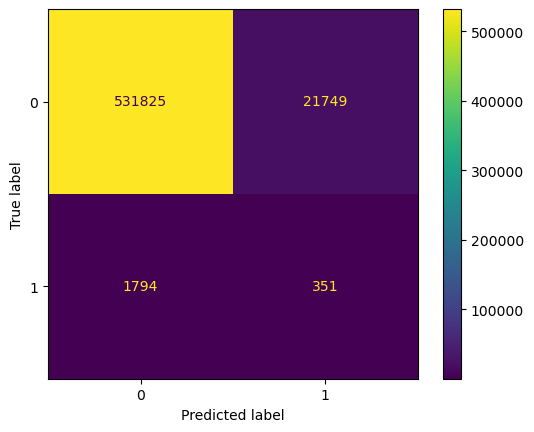

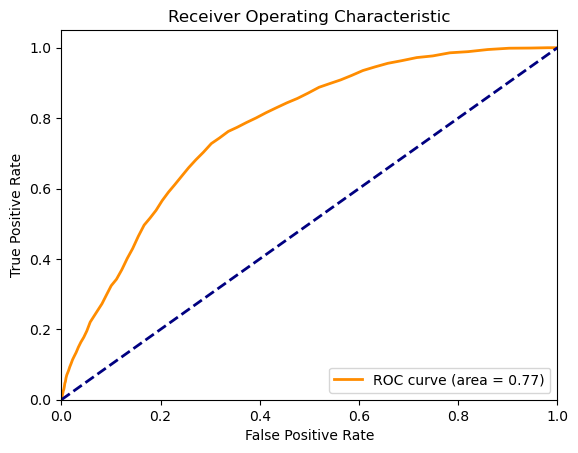

In [57]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

#### Random Forest -

In [62]:
importances_rf = rf_smote.feature_importances_

# Select the top n features or based on a threshold
n_features = 22  # You can also use a threshold approach
indices = np.argsort(importances_rf)[::-1]
selected_features_rf = indices[:n_features]

In [63]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_rf
})

In [64]:
feature_importance_rf.sort_values(by='Importance', ascending=True)

,Feature,Importance
8,year,0.002644
13,location_type,0.004335
15,le_gender,0.006331
14,location_cluster,0.006435
12,distance_to_merchant,0.014198
6,merch_lat,0.016693
7,merch_long,0.017880
9,month,0.017886
1,zip,0.018722
3,long,0.018846


### XGBoost

In [58]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [59]:
y_pred_xgb_smote_train = xgb_model.predict(X_test_unbalanced)
y_prob_xgb_smote_train = xgb_model.predict_proba(X_test_unbalanced)[:, 1]

Accuracy: 0.9922147029903406
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257821
           1       0.42      0.89      0.57      1514

    accuracy                           0.99    259335
   macro avg       0.71      0.94      0.78    259335
weighted avg       1.00      0.99      0.99    259335

ROC AUC Score: 0.938958263758482


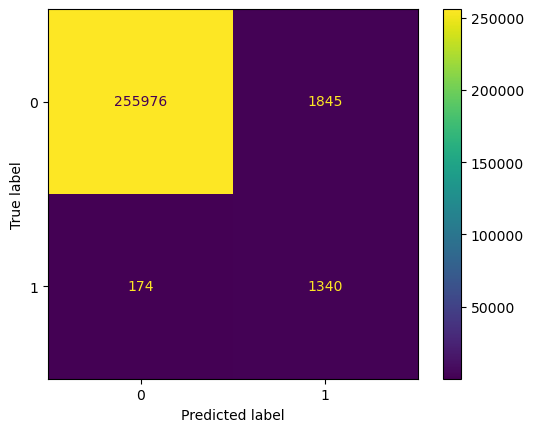

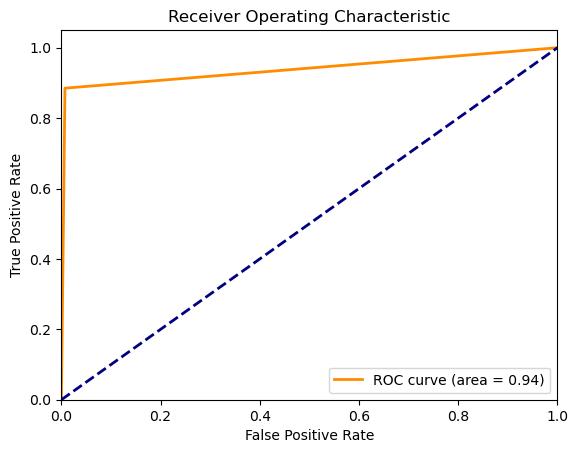

In [60]:
measure_metrics(y_test_unbalanced, y_pred_xgb_smote_train, y_pred_xgb_smote_train)

In [61]:
y_pred_xgb_smote_test = xgb_model.predict(X_test_actual)
y_prob_xgb_smote_test = xgb_model.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.6418711615042855
              precision    recall  f1-score   support

           0       1.00      0.64      0.78    553574
           1       0.01      0.74      0.02      2145

    accuracy                           0.64    555719
   macro avg       0.50      0.69      0.40    555719
weighted avg       0.99      0.64      0.78    555719

ROC AUC Score: 0.732544722333802


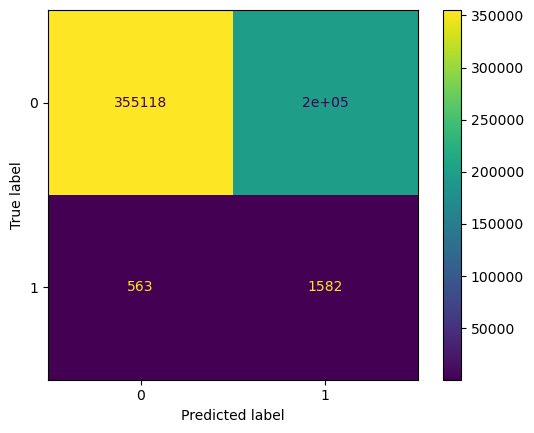

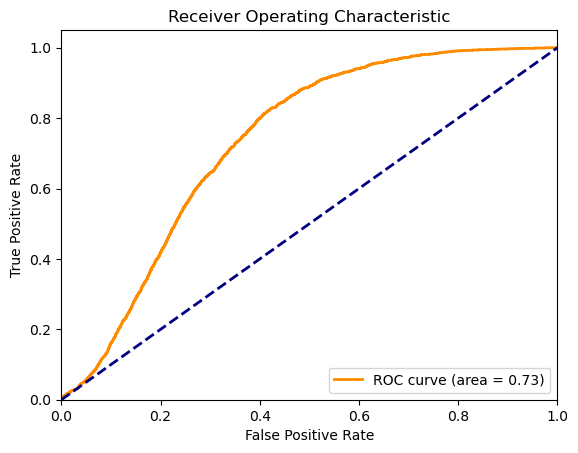

In [62]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test, y_prob_xgb_smote_test)

In [66]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7,8,9,10,11,12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 10, 25, 50, 75, 99],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.1, 1.0, 10.0]
}


In [67]:
xgb_model_tune = xgb.XGBClassifier()

#### Scoring Precision

In [68]:
from sklearn.model_selection import RandomizedSearchCV
xgb_random_search_precision = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='precision', cv=2, verbose=2, 
                                   random_state=42)



In [70]:
xgb_random_search_precision.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.2s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.1s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.9s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.2s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   2.9s
[CV] END 

...

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   0.9s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.3s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.4s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.0s
[CV] END colsa

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200, 300],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='precision', verbose=2)

In [72]:
xgb_random_search_precision.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1,
 'reg_lambda': 10.0,
 'reg_alpha': 0.01,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 0.7}

In [73]:
y_pred_xgb_test_tuned_precision = xgb_random_search_precision.predict(X_test_actual)
y_prob_xgb_test_tuned_precision = xgb_random_search_precision.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9963308794552642
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.67      0.10      0.17      2145

    accuracy                           1.00    555719
   macro avg       0.83      0.55      0.58    555719
weighted avg       1.00      1.00      0.99    555719

ROC AUC Score: 0.9703839326838241


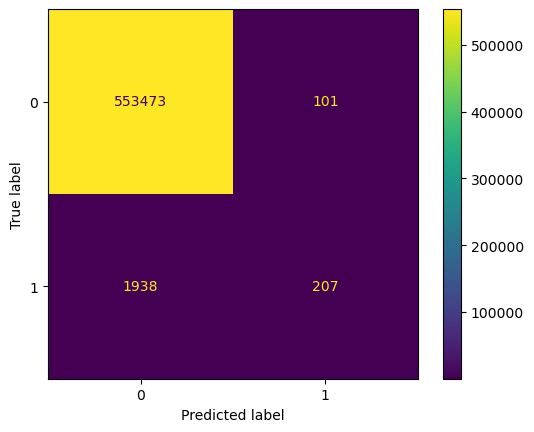

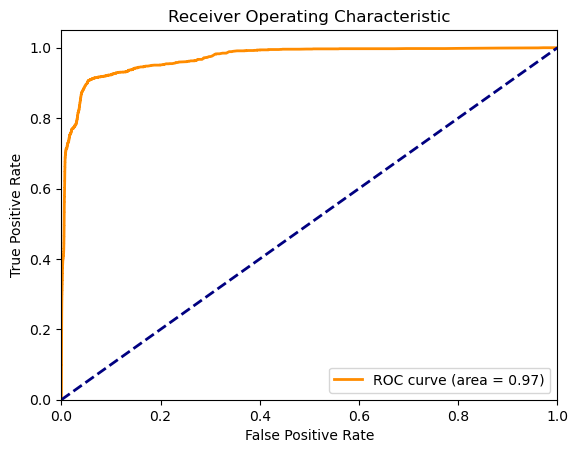

In [74]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_precision, y_prob_xgb_test_tuned_precision)

In [75]:
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

In [76]:
scoring = {
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1': make_scorer(f1_score, average='binary')
}

In [78]:
xgb_random_search_all = RandomizedSearchCV(estimator=xgb_model_tune, 
                                       param_distributions=xgb_param_grid, 
                                       n_iter=100, 
                                       scoring=scoring, 
                                       refit='f1',  # Refit the model based on the F1 score
                                       cv=2, 
                                       verbose=2, 
                                       random_state=42)

In [79]:
xgb_random_search_all.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.4s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.6s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   3.3s
[CV] END 

...

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   1.0s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   1.0s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.1s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.1s
[CV] END colsa

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, refit='f1',
                   scoring={'f1': make_scorer(f1_score, response_method='predict', average=binary),
                            'precision': make_scorer(precision_score, response_method='predict', average=binary),
                            'recall': make_scorer(recall_score, response_method='predict', average=binary)},
                   verbose=2)

In [85]:
xgb_random_search_all.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1,
 'reg_lambda': 1.0,
 'reg_alpha': 0.01,
 'n_estimators': 50,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [86]:
xgb_random_search_all.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [87]:
xgb_random_search_all.best_score_

0.46053956203300916

In [89]:
xgb_random_search_all.cv_results_

{'mean_fit_time': array([0.90585983, 3.28067327, 3.788414  , 4.32089889, 3.73417354,
        0.72602773, 1.03080106, 4.14051485, 3.01312244, 4.29305148,
        1.08938992, 1.15235364, 2.40299153, 1.49256158, 1.28324986,
        1.71628046, 0.8856225 , 3.07963014, 4.06047642, 0.88016248,
        1.61417842, 3.42410445, 1.92351055, 1.09091341, 1.29107594,
        1.22345603, 1.5621165 , 1.12805843, 5.12647903, 2.93284309,
        3.81369555, 3.50359976, 3.71949649, 1.31194985, 0.95804465,
        0.85033405, 1.46200347, 3.5273515 , 2.15839803, 1.01717794,
        1.64860201, 4.39499211, 5.02219844, 0.80160844, 0.69980991,
        0.79424441, 1.27776945, 1.19369137, 1.47897732, 1.54595852,
        2.18845797, 3.38786709, 0.994313  , 1.66844189, 4.16744995,
        1.81133997, 3.31566083, 2.9447701 , 1.01872051, 3.77088094,
        6.37883055, 4.25877893, 0.96988714, 2.99907708, 1.67685103,
        1.91352904, 1.85251594, 3.28768706, 1.7487185 , 1.83445907,
        1.40158355, 1.02466059,

In [83]:
y_pred_xgb_test_tuned_all = xgb_random_search_all.predict(X_test_actual)
y_prob_xgb_test_tuned_all = xgb_random_search_all.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9927283393225713
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.17      0.23      0.20      2145

    accuracy                           0.99    555719
   macro avg       0.58      0.61      0.60    555719
weighted avg       0.99      0.99      0.99    555719

ROC AUC Score: 0.9654589886311391


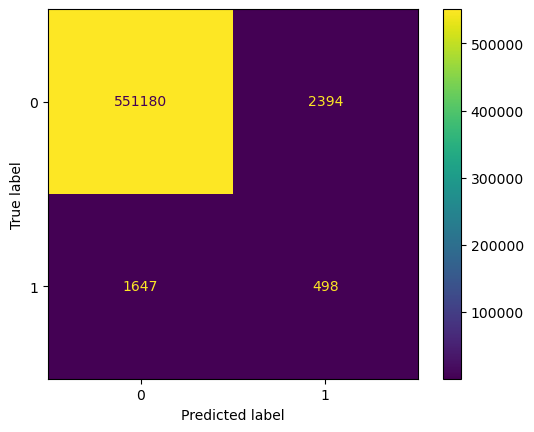

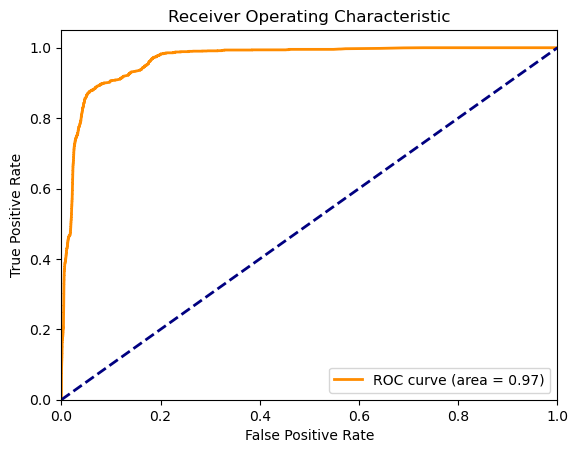

In [84]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_all, y_prob_xgb_test_tuned_all)

### Training in Test data

In [90]:
# Resample the dataset
X_train_smote_test, y_train_smote_test = smote.fit_resample(X_test_actual, y_test_actual)

In [91]:
xgb_random_search_test_recall = RandomizedSearchCV(estimator=xgb_model_tune, 
                                       param_distributions=xgb_param_grid, 
                                       n_iter=100, 
                                       scoring='recall', 
                                       cv=2, 
                                       verbose=2, 
                                       random_state=42)

In [92]:
xgb_random_search_test_recall.fit(X_train_smote_test, y_train_smote_test)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.1s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=75, subsample=0.9; total time=   3.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=75, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.7; total time=   1.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=50, subsample=0.7; total time=   1.1s
[CV] END col

[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=99, subsample=0.9; total time=   4.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=99, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=1, subsample=0.7; total time=   0.9s
[CV] END colsampl

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=0.1, scale_pos_weight=25, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=0.1, scale_pos_weight=25, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=25, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=25, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=99, subsample=0.7; total time=   2.0s
[C

[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=11, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   6.0s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=11, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=25, subsample=0.7; total time=   4.0s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=25, subsample=0.7; total time=   3.8s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   3.2s
[C

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200, 300],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='recall', verbose=2)

In [93]:
y_pred_xgb_test_tuned_recall_test = xgb_random_search_test_recall.predict(X)
y_prob_xgb_test_tuned_recall_test = xgb_random_search_test_recall.predict_proba(X)[:, 1]

xgb_random_search_test_recall.best_params_

In [96]:
xgb_random_search_test_recall.best_score_

1.0

Accuracy: 0.005844178379316329
              precision    recall  f1-score   support

           0       1.00      0.00      0.00   1289169
           1       0.01      1.00      0.01      7506

    accuracy                           0.01   1296675
   macro avg       0.50      0.50      0.01   1296675
weighted avg       0.99      0.01      0.00   1296675

ROC AUC Score: 0.9011013130399731


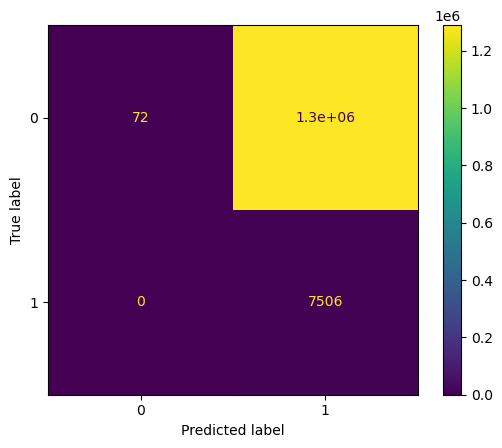

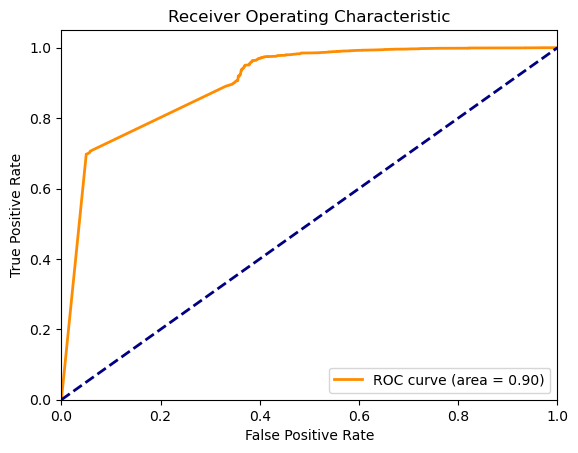

In [94]:
measure_metrics(y, y_pred_xgb_test_tuned_recall_test, y_prob_xgb_test_tuned_recall_test)

In [117]:
xgb_tuned_on_test_data = xgb.XGBClassifier(
    subsample=1,
    reg_lambda=0.1,
    reg_alpha=0.01,
    n_estimators=50,
    min_child_weight=5,
    max_depth=1,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.8
)


In [118]:
xgb_tuned_on_test_data.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [119]:
y_pred_xgb_tuned_on_test_data = xgb_tuned_on_test_data.predict(X_test_actual)
y_prob_xgb_tuned_on_test_data = xgb_tuned_on_test_data.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9564132232297258
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

ROC AUC Score: 0.9450760021193242


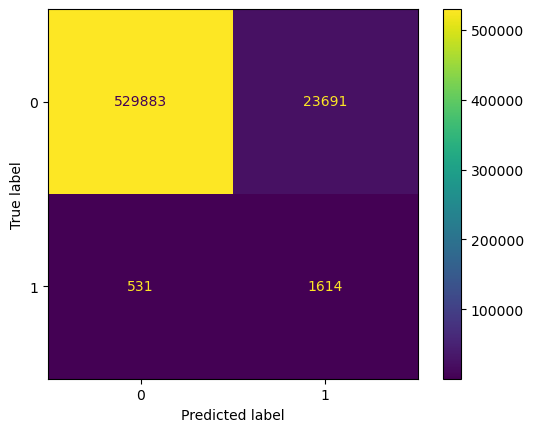

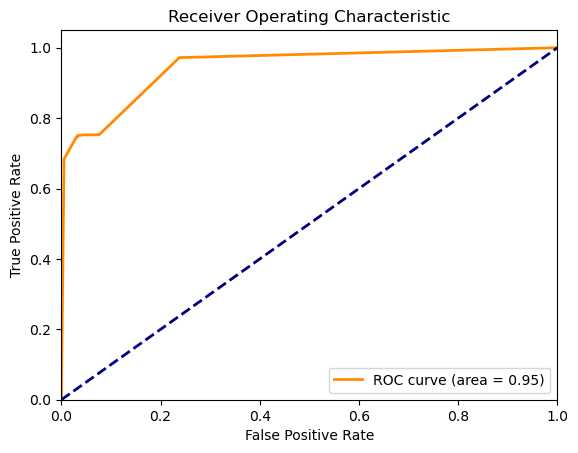

In [120]:
measure_metrics(y_test_actual, y_pred_xgb_tuned_on_test_data, y_prob_xgb_tuned_on_test_data)

#### Scoring in Recall (balanced)

In [90]:
xgb_random_search_balanced_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [85]:
xgb_random_search_recall.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   5.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.6s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.6s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   6.0s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   5.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=   7.4s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.1s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.3s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [92]:
y_pred_xgb_test_tuned_recall = xgb_random_search_recall.predict(X_test_actual)
y_prob_xgb_test_tuned_recall = xgb_random_search_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


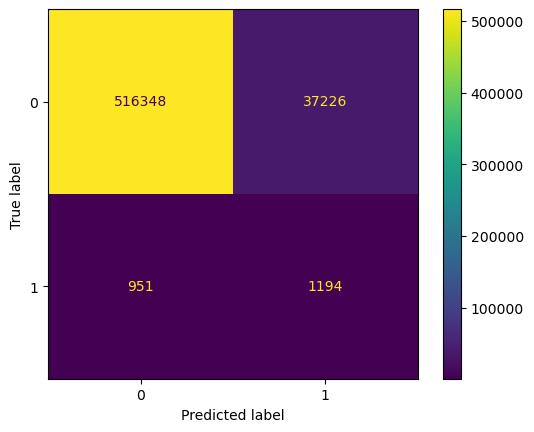

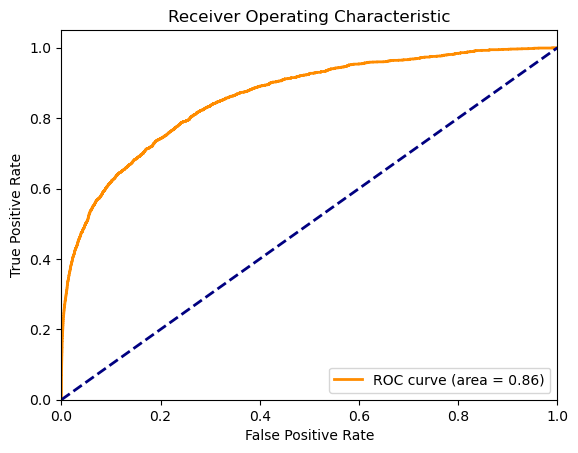

In [93]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_recall, y_prob_xgb_test_tuned_recall)

In [ ]:
#### Scoring in 

#### Scoring in Recall (balanced)

In [84]:
xgb_random_search_smote_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [91]:
xgb_random_search_recall.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   8.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.9s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.2s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   7.0s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  16.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  15.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.1s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=  10.3s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.8s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [98]:
y_pred_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict(X_test_actual)
y_prob_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


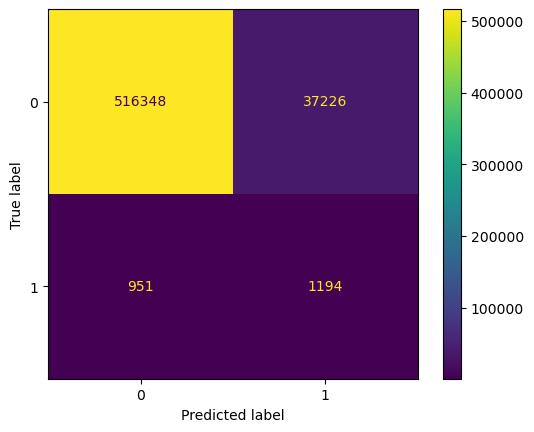

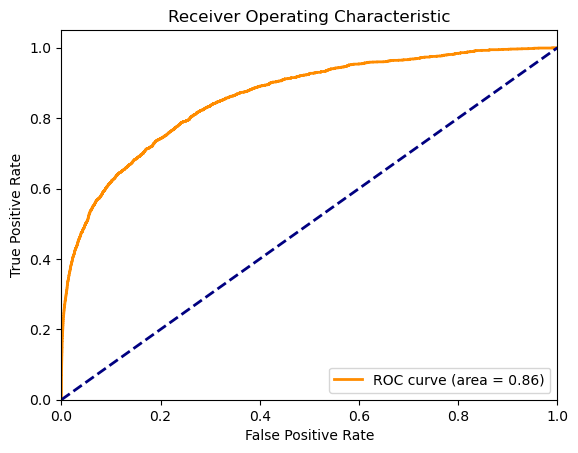

In [99]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test_tuned_recall, y_prob_xgb_smote_test_tuned_recall)